Shape: 5,000 rows × 32 columns
             Timestamp Track_Block_ID Sensor_ID   Voltage_V  Current_A  \
0  2025-01-01 00:00:00             B7       S16  259.524315  14.005650   
1  2025-01-01 00:00:01            B20        S2  212.358746   2.553015   
2  2025-01-01 00:00:02            B15       S28  227.474344   4.809501   

   Temperature_C  Vibration_m_s2  Relay_Status  Timer_TON_ms  Timer_TCH_ms  \
0      33.757837             2.5             1    174.074803    215.646177   
1      38.999337             2.5             1    290.189646    518.109570   
2      25.726627             2.5             1    420.570923    196.167375   

   ...  HMI_Alert_Code  Failure_Type  Component_Age_days Maintenance_Action  \
0  ...              A2            C6         1870.699559     Clean Contacts   
1  ...              A2            C6         2608.191861      Replace Timer   
2  ...              A2            C7         2800.000000    Lubricate Relay   

   RUL_Predicted_days  Edge_Anomaly_Score 

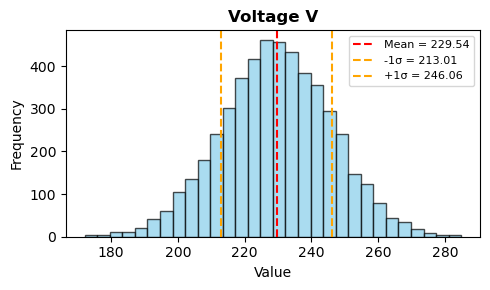

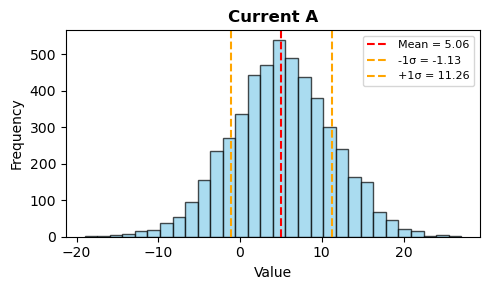

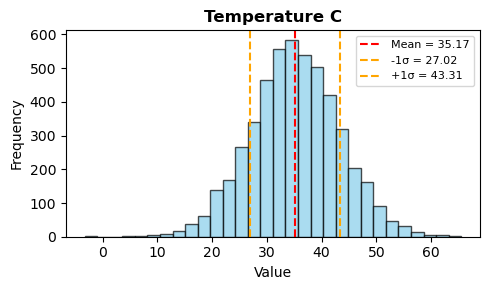

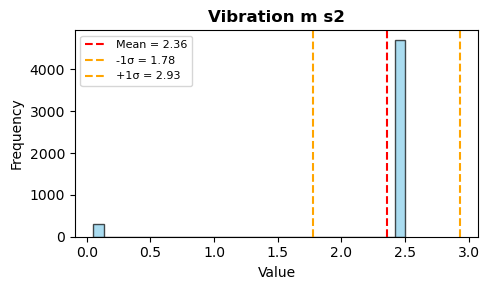

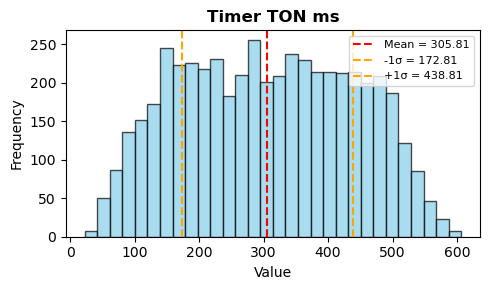

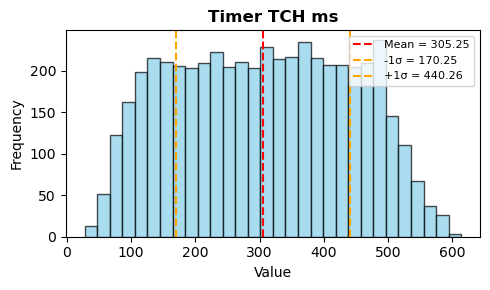

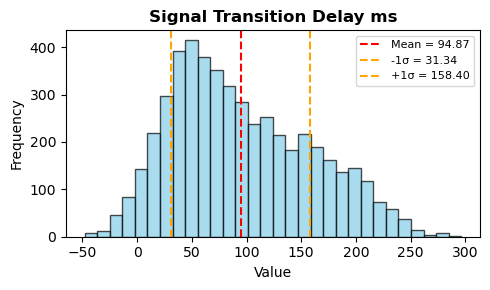

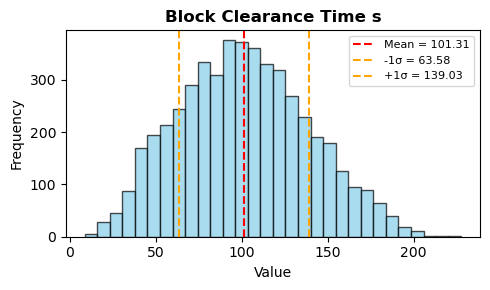

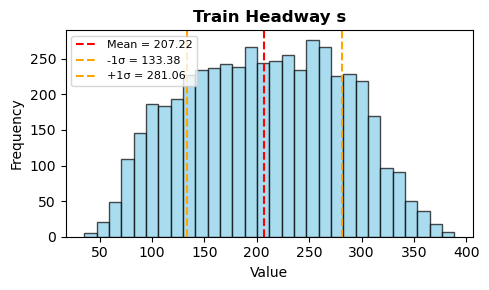

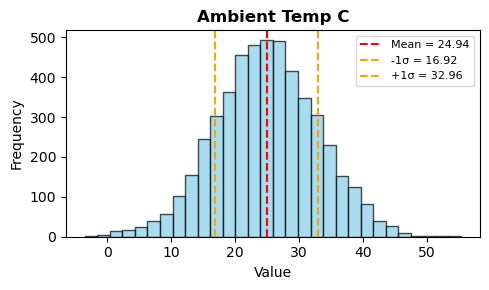

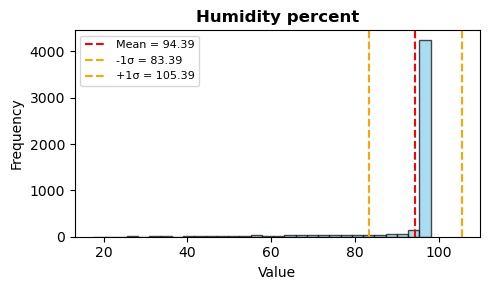

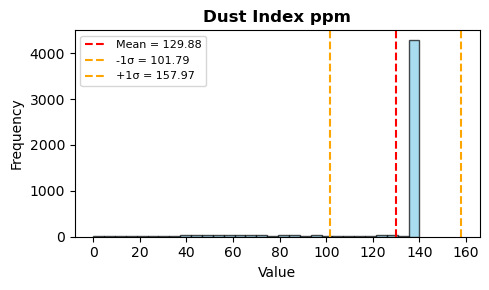

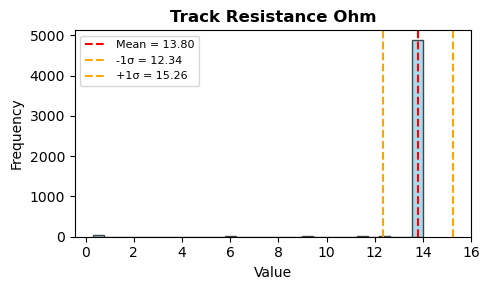

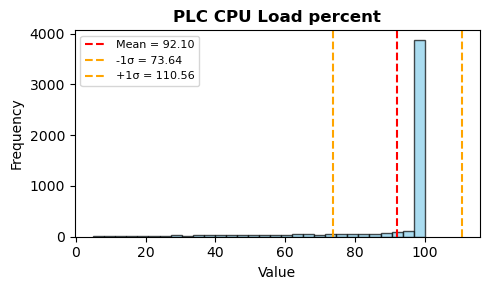

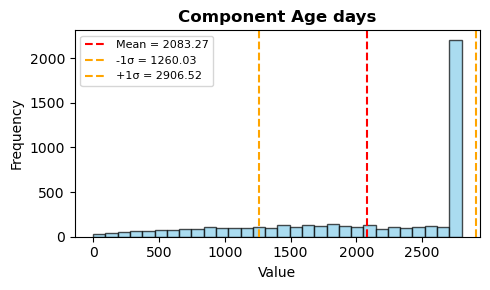

In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# Path to the CSV file
CSV_PATH = "RT_PLC_RSFPD.csv"
# Read the data from the CSV file
df = pd.read_csv(CSV_PATH)
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(df.head(3))  # Display the first 3 rows of the DataFrame
# Define the target column and numerical columns
TARGET = "Predicted_Failure_Prob"  # Replace with the actual target column in your CSV
COLUMN_NAMES = [
    "Voltage_V", "Current_A", "Temperature_C", "Vibration_m_s2",
    "Timer_TON_ms", "Timer_TCH_ms",
    "Signal_Transition_Delay_ms", "Block_Clearance_Time_s", "Train_Headway_s",
    "Ambient_Temp_C", "Humidity_percent", "Dust_Index_ppm",
    "Track_Resistance_Ohm", "PLC_CPU_Load_percent",
    "Component_Age_days"
]
# Check if all columns in COLUMN_NAMES exist in the DataFrame
missing_cols = [col for col in COLUMN_NAMES if col not in df.columns]
if missing_cols:
    print(f"Warning: The following columns are missing in the CSV file: {missing_cols}")
    COLUMN_NAMES = [col for col in COLUMN_NAMES if col in df.columns]
# Number of columns to process
n = len(COLUMN_NAMES)
print(f"Number of columns to plot = {n}")
# Loop through each feature and plot its histogram
for i, col in enumerate(COLUMN_NAMES):
    data = df[col].dropna()  # Drop missing values for the column
    mu, sigma = data.mean(), data.std()  # Calculate mean and standard deviation
    # Create a new figure for each feature
    plt.figure(figsize=(5, 3))    
    # Plot histogram
    plt.hist(data, bins=30, color="skyblue", alpha=0.7, edgecolor="black")
    # Add mean and standard deviation lines
    plt.axvline(mu, color="red", linestyle="--", label=f"Mean = {mu:.2f}")
    plt.axvline(mu - sigma, color="orange", linestyle="--", label=f"-1σ = {mu - sigma:.2f}")
    plt.axvline(mu + sigma, color="orange", linestyle="--", label=f"+1σ = {mu + sigma:.2f}")
    # Add title and labels
    plt.title(col.replace("_", " "), fontsize=12, fontweight="bold")
    plt.xlabel("Value", fontsize=10)
    plt.ylabel("Frequency", fontsize=10)
    plt.legend(fontsize=8)
    plt.tight_layout()
    # Show the plot
    plt.show()

Pearson r with target: 'Predicted_Failure_Prob'
  Voltage_V                       r = +0.0154   p = 0.2757  no
  Current_A                       r = -0.0081   p = 0.5686  no
  Temperature_C                   r = +0.0014   p = 0.9213  no
  Vibration_m_s2                  r = +0.3611   p = 0.0000  yes
  Timer_TON_ms                    r = +0.1870   p = 0.0000  yes
  Timer_TCH_ms                    r = +0.2103   p = 0.0000  yes
  Signal_Transition_Delay_ms      r = +0.8820   p = 0.0000  yes
  Block_Clearance_Time_s          r = +0.6310   p = 0.0000  yes
  Train_Headway_s                 r = +0.3170   p = 0.0000  yes
  Ambient_Temp_C                  r = -0.0132   p = 0.3509  no
  Humidity_percent                r = +0.4926   p = 0.0000  yes
  Dust_Index_ppm                  r = +0.5581   p = 0.0000  yes
  Track_Resistance_Ohm            r = +0.2323   p = 0.0000  yes
  PLC_CPU_Load_percent            r = +0.5903   p = 0.0000  yes
  Component_Age_days              r = +0.8158   p = 0.0000  

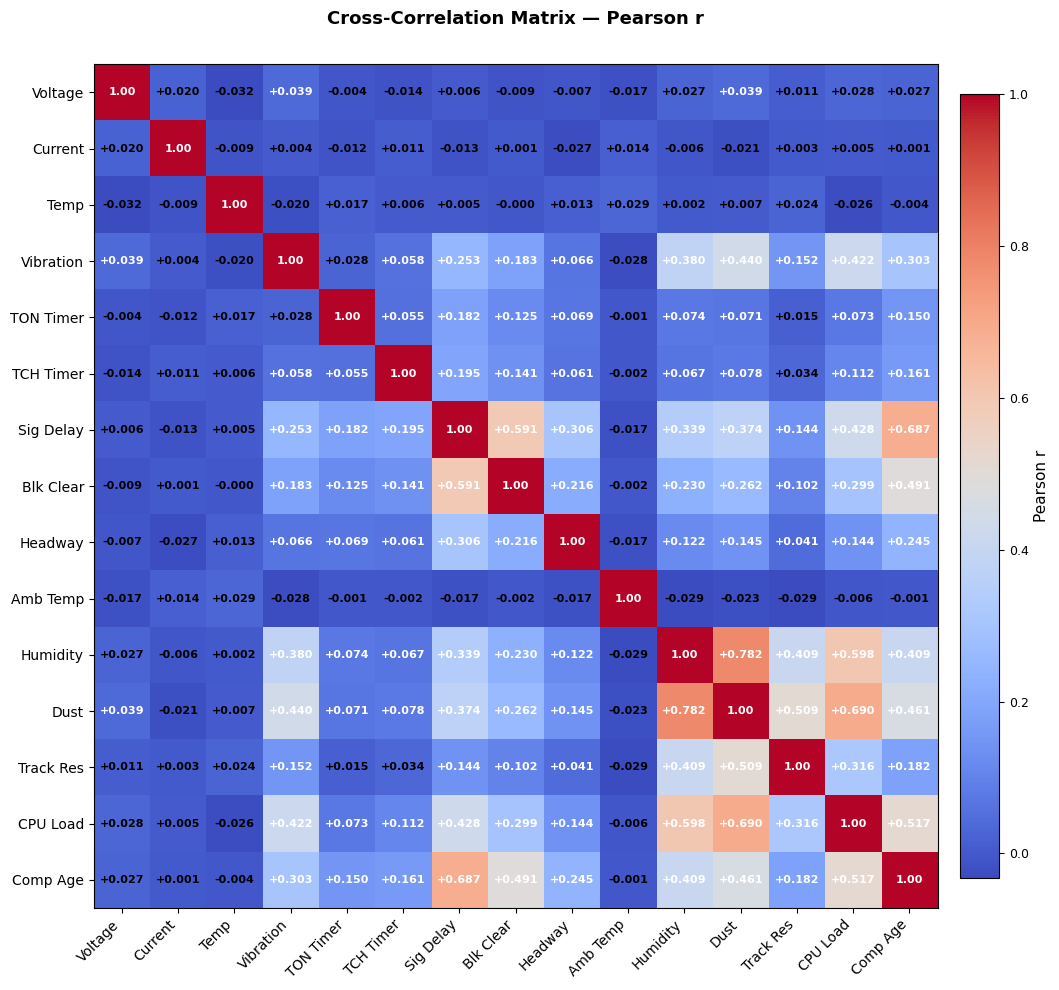

In [59]:
import matplotlib.gridspec as gridspec
from scipy import stats
import matplotlib.colors as mcolors
# Pearson r for Target
print(f"Pearson r with target: '{TARGET}'")
target_corrs = [] # Empty list
for col in COLUMN_NAMES:
    valid = df[[col, TARGET]].dropna() # Remove missing values (NaN or None)
    r, p = stats.pearsonr(valid[col], valid[TARGET])
    target_corrs.append({"Feature": col, "r": r, "p": p})
    if p < 0.05:
        sig = 'yes'
    else:
        sig = 'no' 
    
    print(f"  {col:<30}  r = {r:+.4f}   p = {p:.4f}  {sig}")
 
# Define a function to extract the absolute value of r
def get_abs_r(corr):
    return abs(corr["r"])
# Sort the list by absolute value of r in descending order
sorted_corrs = sorted(target_corrs, key=get_abs_r, reverse=True)
# Print the top 5 correlations
print("\nTop 5 features by |r|:")
for i, corr in enumerate(sorted_corrs[:5], 1):  # Get the top 5
    print(f"{i}. {corr['Feature']:<30}  r = {corr['r']:+.4f}")

""" Cross-correlation matrix and use significant pairs"""
r_mat = np.ones((n, n))
p_mat = np.ones((n, n))
for i in range(n):
    for j in range(n):
        if i != j:
            valid = df[[COLUMN_NAMES[i], COLUMN_NAMES[j]]].dropna()
            r_mat[i, j], p_mat[i, j] = stats.pearsonr(valid.iloc[:, 0], valid.iloc[:, 1])
corr_df = pd.DataFrame(r_mat, index=COLUMN_NAMES, columns=COLUMN_NAMES)

# Significant pairs
print("\nSignificant feature pairs (p < 0.05):")
print("-" * 60)
found = False
for i in range(n):
    for j in range(i + 1, n):
        if p_mat[i, j] < 0.05:
            print(f"  {COLUMN_NAMES[i]:<30}  <->  {COLUMN_NAMES[j]:<30}  r = {r_mat[i,j]:+.4f}  p = {p_mat[i,j]:.4f}")
            found = True
if not found:
    print("  None found at p < 0.05")
 
# Heatmap plot
# DEFINE shortnames for better visualization
SHORT = [
    "Voltage", "Current", "Temp", "Vibration",
    "TON Timer", "TCH Timer", "Sig Delay", "Blk Clear", "Headway",
    "Amb Temp", "Humidity", "Dust", "Track Res", "CPU Load", "Comp Age"
]

cmap = plt.cm.coolwarm  # Predefined colormap with a blue-to-red gradient
# Heatmap plot
fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(r_mat, cmap=cmap)
# Colorbar
cbar = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.02)
cbar.set_label("Pearson r", fontsize=11)
cbar.ax.tick_params(labelsize=9)
# Axis labels
ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(SHORT, rotation=45, ha="right", fontsize=10)
ax.set_yticklabels(SHORT, fontsize=10)
# Cell annotations
for i in range(n):
    for j in range(n):
        r = r_mat[i, j]
        p = p_mat[i, j]
        if i == j:
            txt = "1.00"
            color = "white"
        else:
            txt = f"{r:+.3f}"# use the r value
            color = "white" if abs(r) > 0.035 else "black"
        ax.text(j, i, txt, ha="center", va="center", fontsize=8, color=color, fontweight="bold")
# Grid lines
ax.grid(False)  # Disable grid lines for a cleaner look
# Title
ax.set_title(
    "Cross-Correlation Matrix — Pearson r\n",
    fontsize=13, fontweight="bold", pad=14
)
plt.tight_layout()
plt.show()

In [72]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler  # Import StandardScaler
# Extract features and target
X = df[COLUMN_NAMES].dropna()
y = df.loc[X.index, TARGET]
# The y prediction values are divided into three categories for risk based on their distribution
y_cat = pd.qcut(y, q=3, labels=[0, 1, 2])
# Split: 60% train, 40% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y_cat, test_size=0.40, random_state=11, stratify=y_cat
)
print(f"Training samples : {len(X_train):,}")
print(f"Testing  samples : {len(X_test):,}")

# Scale features 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
# Fit LDA
lda = LinearDiscriminantAnalysis()
lda.fit(X_train_scaled, y_train)
# Predict
y_pred = lda.predict(X_test_scaled)
# Evaluation
print("\n── Accuracy ──────────────────────────────")
print(f"  {accuracy_score(y_test, y_pred):.4f}")
print("\n── Confusion Matrix ──────────────────────")
print(confusion_matrix(y_test, y_pred))

Training samples : 3,000
Testing  samples : 2,000

── Accuracy ──────────────────────────────
  0.8315

── Confusion Matrix ──────────────────────
[[564 103   0]
 [ 78 519  69]
 [  0  87 580]]


In [76]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler
# Use X_train_scaled, y_train, X_test_scaled values from the above experiment
print(f"Training samples : {len(X_train):,}")
print(f"Testing  samples : {len(X_test):,}")

# Fit MLP
mlp = MLPClassifier(
    hidden_layer_sizes=(256, 128),   # two hidden layers
    activation="relu",
    solver="adam",
    max_iter=500,
    random_state=11,
    early_stopping=True,            
    validation_fraction=0.1,
    n_iter_no_change=15,
    verbose=True
)
mlp.fit(X_train_scaled, y_train)

# Predict
y_pred = mlp.predict(X_test_scaled)

# Evaluation
print("\n── Accuracy ──────────────────────────────")
print(f"  {accuracy_score(y_test, y_pred):.4f}")

print("\n── Confusion Matrix ──────────────────────")
print(confusion_matrix(y_test, y_pred))



Training samples : 3,000
Testing  samples : 2,000
Iteration 1, loss = 0.84051047
Validation score: 0.816667
Iteration 2, loss = 0.47678670
Validation score: 0.836667
Iteration 3, loss = 0.37176999
Validation score: 0.863333
Iteration 4, loss = 0.34309732
Validation score: 0.873333
Iteration 5, loss = 0.32600407
Validation score: 0.880000
Iteration 6, loss = 0.31715926
Validation score: 0.866667
Iteration 7, loss = 0.30893790
Validation score: 0.876667
Iteration 8, loss = 0.30418923
Validation score: 0.880000
Iteration 9, loss = 0.29757263
Validation score: 0.860000
Iteration 10, loss = 0.29460657
Validation score: 0.863333
Iteration 11, loss = 0.29732336
Validation score: 0.863333
Iteration 12, loss = 0.28937464
Validation score: 0.873333
Iteration 13, loss = 0.28303748
Validation score: 0.866667
Iteration 14, loss = 0.27815411
Validation score: 0.873333
Iteration 15, loss = 0.27383067
Validation score: 0.870000
Iteration 16, loss = 0.27064250
Validation score: 0.873333
Iteration 17, l